# Exploratory Data Analysis (EDA)

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

plt.style.use("default")

In [3]:
data = pd.read_csv("../data/raw/telco_churn.csv") # Pandas DataFrame
data.head() # First five rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Shape and schema
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


- The dataset contains 7043 observations
- There are 20 input features and 1 binary target variable ("Churn")
- "TotalCharges" column is stored as an object data type, which indicates that there are non-numeric values, requriing cleaning and conversion before modelling commences. 

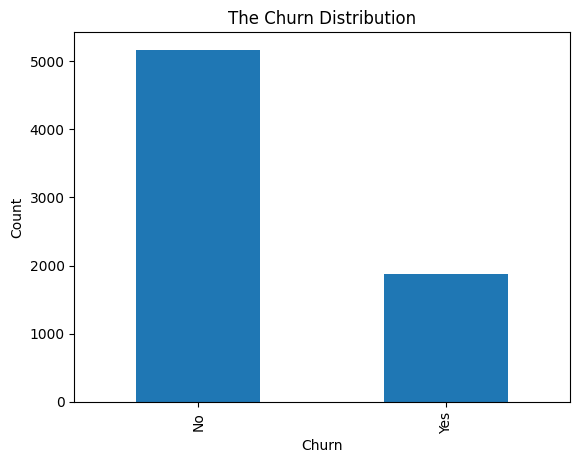

In [6]:
data["Churn"].value_counts(normalize = True) # Distribution of target values

# Plotting the target values
ax = data["Churn"].value_counts().plot(kind = "bar")
ax.set_title("The Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
plt.show()

- There is a modern imbalance in the target variable. Non-churn customers form the more dominant class.
- Therefore, accuracy itself would not be appropriate, as it the results would be misleading.
- ROC, AUC, precision, recall, and the F1-score will provide more reliable and meaningful results 
- Class imbalance encourages the use of class weighting or threshold tuning techniques

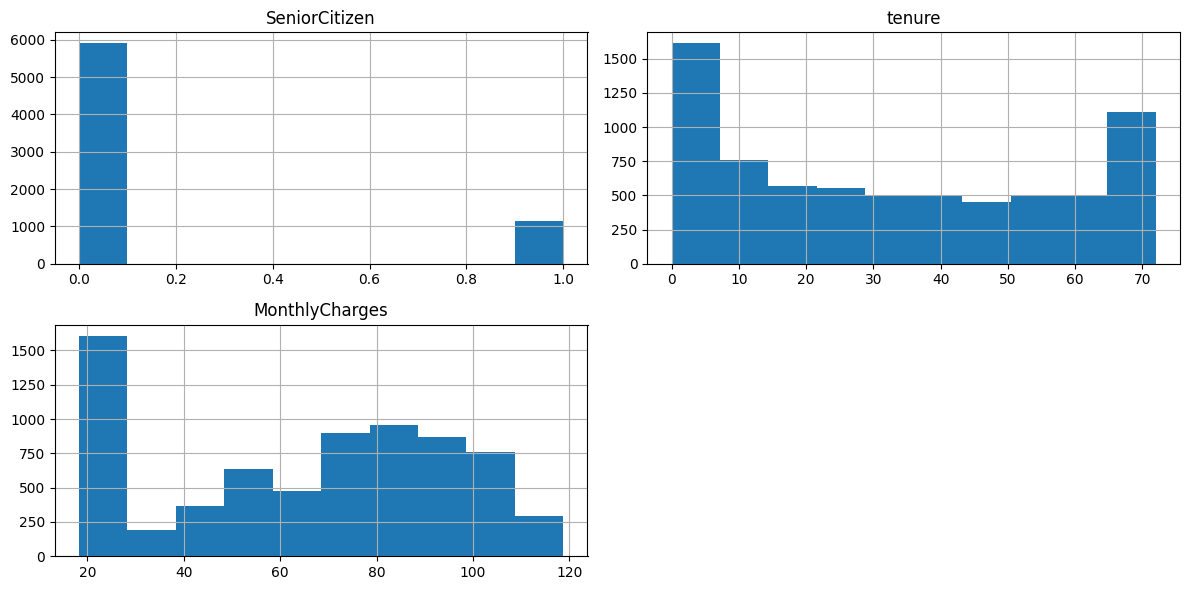

In [ ]:
data.describe() # The numeric features

# Plotting a histogram for SenorCitizen, MonthlyCharges, and tenure.
data.hist(figsize = (12, 6))
plt.tight_layout()
plt.show()

- "SeniorCitizen" is not a continuous numeric feature and will be treated as a categorical data type for modelling
- "tenure" shows a long tail towards higher tenure and a strong skew towards shorter tenure.
- "MonthlyCharges" shows a multimodal distribution, a clear separation between customers who spend less and those that spend more money. 

In [8]:
# Check the categories that are strongly associated with Churn
pd.crosstab(data["Contract"], data["Churn"], normalize = "index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


- It looks like month-to-month contracts show a substantially higher churn rate than long term contracts. 

In [9]:
# Data quality check
data.isna().sum()

# Inspecting the TotalCharges data type
data["TotalCharges"].dtype

dtype('O')

- "TotalCharges" shows no missing values but it is stored as an object data type. This indicates that conversion may be needed during preprocessing. 

## Initial Hypothesis

- Customers with month-to-month contracts are more likely to churn compared to customers with long term contracts.
- Short tenure correlates with increased churn risk.
- Higher monthly charges, for those with short tenure or flexible contracts, correlates with increased churn.

In [12]:
# Converting TotalCharges into a numeric data type (force errors into NaN)
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors = "coerce")

# Checking how many NaNs were introduced
data["TotalCharges"].isna().sum()

np.int64(11)

In [13]:
# Handling the NaNs
data = data.dropna(subset = ["TotalCharges"])

- The "TotalCharges" column coverted to a numeric data type, and any invalid observations were deleted on basis of maintaining consistency before modelling. 

In [14]:
# Separating the features and the target
X = data.drop(columns = ["Churn", "customerID"])
y = data["Churn"].map({"No" : 0, "Yes" : 1})

# Sanity check
X.shape, y.shape

((7032, 19), (7032,))

In [15]:
# Identifying the feature data types
features_numeric = X.select_dtypes(include = ["int64", "float64"]).columns.tolist()
features_categorical = X.select_dtypes(include = ["object"]).columns.tolist()

features_numeric, features_categorical

(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

- Modelling and preprocessing steps are in continued in 02_preprocessing_and_baseline_model.ipynb